In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import open3d as o3d


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


LẤY BOUNDING BOX ĐÃ DETECT = YOLO

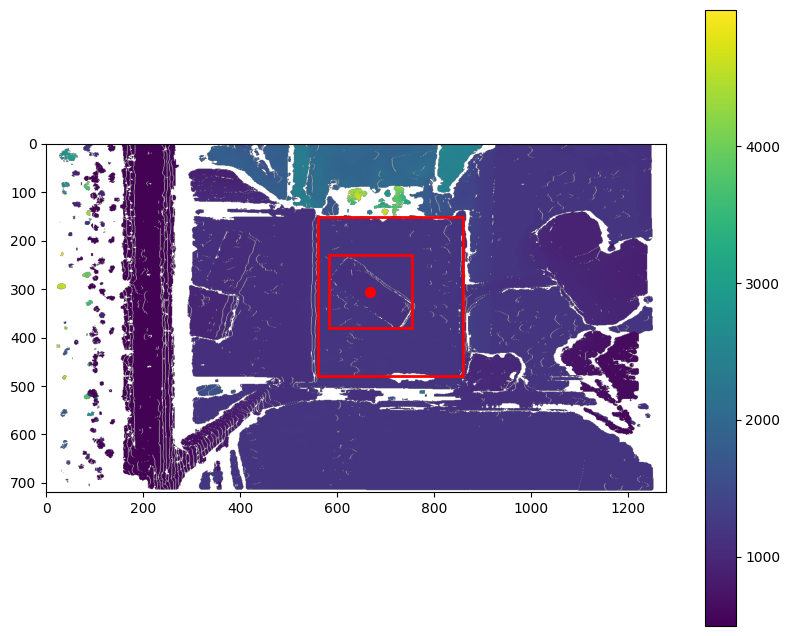

In [6]:
depth = cv2.imread(r"C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\depth\0149.png", cv2.IMREAD_UNCHANGED)
valid_mask = (depth > 0) & (depth < 5000)
depth_disp = np.where(valid_mask, depth, np.nan)

roi_x, roi_y, roi_w, roi_h = 560, 150, 300, 330
box_x_min, box_x_max, box_y_min, box_y_max = 584, 754, 230, 380

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(depth_disp, cmap='viridis')

rect = patches.Rectangle((roi_x, roi_y), roi_w, roi_h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

rect2 = patches.Rectangle((box_x_min, box_y_min), box_x_max-box_x_min, box_y_max-box_y_min, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect2)

ax.scatter(669.0, 305.0, c='r', s=50) # thử vẽ tâm

plt.colorbar(im)
plt.show()


In [4]:
bounding_box_z = depth[box_y_min:box_y_max+1, box_x_min:box_x_max+1]
bounding_box_z

array([[1126, 1125, 1125, ..., 1197, 1197, 1195],
       [1125, 1125, 1124, ..., 1197, 1197, 1197],
       [1125, 1124, 1123, ..., 1198, 1197, 1197],
       ...,
       [1133, 1132, 1132, ..., 1195, 1196, 1197],
       [1133, 1133, 1132, ..., 1196, 1197, 1199],
       [1132, 1132, 1131, ..., 1197, 1198, 1200]], dtype=uint16)

[55 59 59]


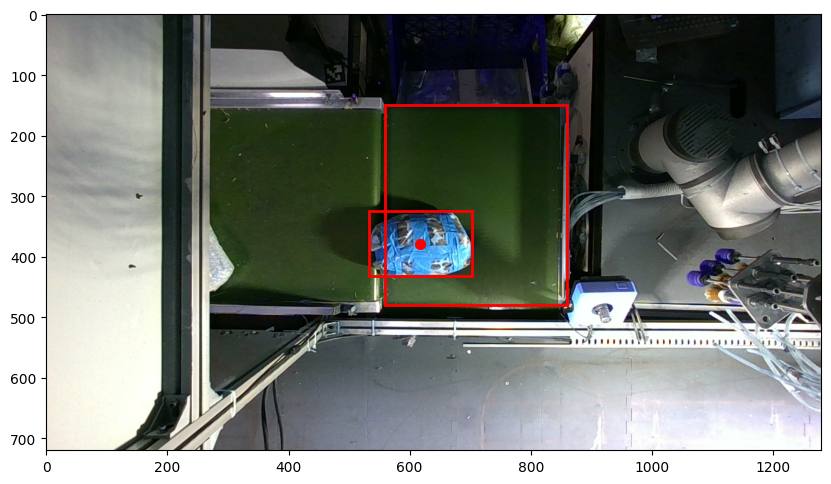

In [5]:
img = cv2.imread(r"C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\rgb\0000.png", cv2.IMREAD_UNCHANGED)
img.shape

print(img[int(617.5), int(378.5)])

roi_x, roi_y, roi_w, roi_h = 560, 150, 300, 330
box_x_min, box_x_max, box_y_min, box_y_max = 532, 703, 325, 432

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(img)

rect = patches.Rectangle((roi_x, roi_y), roi_w, roi_h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

rect2 = patches.Rectangle((box_x_min, box_y_min), box_x_max-box_x_min, box_y_max-box_y_min, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect2)

ax.scatter(617.5, 378.5, c='r', s=50)


plt.show()

In [6]:
bounding_box_color = img[box_y_min:box_y_max+1, box_x_min:box_x_max+1]
bounding_box_color

array([[[21, 34, 13],
        [21, 34, 13],
        [22, 35, 14],
        ...,
        [44, 68, 29],
        [43, 67, 28],
        [45, 69, 30]],

       [[21, 35, 11],
        [21, 35, 11],
        [22, 36, 12],
        ...,
        [39, 63, 24],
        [44, 68, 29],
        [46, 70, 31]],

       [[21, 34, 13],
        [21, 34, 13],
        [21, 34, 13],
        ...,
        [49, 73, 34],
        [49, 73, 34],
        [46, 70, 31]],

       ...,

       [[58, 80, 39],
        [58, 80, 39],
        [55, 78, 34],
        ...,
        [53, 71, 42],
        [56, 71, 43],
        [47, 62, 34]],

       [[59, 82, 38],
        [59, 82, 38],
        [61, 84, 40],
        ...,
        [53, 71, 42],
        [56, 71, 43],
        [47, 62, 34]],

       [[58, 81, 37],
        [57, 80, 36],
        [61, 84, 40],
        ...,
        [50, 68, 39],
        [48, 66, 37],
        [45, 63, 34]]], dtype=uint8)

In [7]:
color_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 643.90087890625,
    'fy': 643.1365356445312,
    'cx': 650.2113037109375,
    'cy': 355.79559326171875,
    'model': "distortion.inverse_brown_conrady",
    'coeffs': [-0.05658450722694397, 0.06544225662946701,-0.0008694113348610699, 0.00016751799557823688,-0.020957745611667633]
}

depth_intrinsics = {
    'width': 1280,
    'height': 720,
    'fx': 650.0616455078125,
    'fy': 650.0616455078125,
    'cx': 649.5928955078125,
    'cy': 360.9415588378906,
    'model': "distortion.brown_conrady",
    'coeffs': [0.0, 0.0, 0.0, 0.0, 0.0]
}

R_depth_to_color = np.array([[0.9999898076057434, -0.00020347206736914814, -0.004507721401751041],
    [0.00018898719281423837, 0.9999948143959045, -0.0032135415822267532],
    [0.004508351907134056, 0.003212657058611512, 0.9999846816062927]])
t_depth_to_color = np.array([[-0.05905],
    [8.67399e-5],
    [0.00041]])

POINT CLOUD VỚI DEPTH RỒI CHUYỂN VỀ HỆ COLOR = EXTRINSIC (Chỉ lấy point cloud trong bounding box)

In [8]:
bounding_box_z.shape

(108, 172)

In [26]:
u.shape

(108, 172)

In [27]:
v.shape

(3,)

In [9]:
h, w = bounding_box_z.shape

# Depth -> 3D = depth intrinsic
# u,v are local to the cropped bounding-box. Add box offsets to get full-image pixel coords
u, v = np.meshgrid(np.arange(w), np.arange(h))
Z = bounding_box_z.astype(np.float32) / 1000.0  # meters
# mask invalid depths (zeros or very far values)
valid_depth = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)

# full-image pixel coordinates
u_full = u + box_x_min
v_full = v + box_y_min

# back-project using depth intrinsics (use full-image pixel coords)
X = (u_full - depth_intrinsics['cx']) * Z / depth_intrinsics['fx']
Y = (v_full - depth_intrinsics['cy']) * Z / depth_intrinsics['fy']

points_depth = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
valid_flat = valid_depth.reshape(-1)
points_depth_valid = points_depth[valid_flat]

# Transform to color camera frame
points_color = (R_depth_to_color @ points_depth_valid.T).T + t_depth_to_color.reshape(1, 3)

# Project to color image (color intrinsics) and filter by positive depth
Xc = points_color[:, 0]
Yc = points_color[:, 1]
Zc = points_color[:, 2]
valid_z = Zc > 1e-6
Xc = Xc[valid_z]; Yc = Yc[valid_z]; Zc = Zc[valid_z]
points_color = points_color[valid_z]

u_c = np.round(Xc * color_intrinsics['fx'] / Zc + color_intrinsics['cx']).astype(np.int32)
v_c = np.round(Yc * color_intrinsics['fy'] / Zc + color_intrinsics['cy']).astype(np.int32)

# Sample colors from the full color image `img` (not from the cropped bounding_box_color)
h_img, w_img = img.shape[:2]
in_bounds = (u_c >= 0) & (u_c < w_img) & (v_c >= 0) & (v_c < h_img)
u_c = u_c[in_bounds]; v_c = v_c[in_bounds]
points_color_valid = points_color[in_bounds]
colors = img[v_c, u_c] / 255.0

# create point cloud and save
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_color_valid)
pcd.colors = o3d.utility.Vector3dVector(colors)
o3d.io.write_point_cloud("output.ply", pcd)


True

In [10]:
X.shape, Y.shape, Z.shape

((108, 172), (108, 172), (108, 172))

In [11]:
points_depth = np.stack((X, Y, Z), axis=-1).reshape(-1,3)
points_depth.T.shape

(3, 18576)

In [12]:
R_depth_to_color.shape

(3, 3)

In [13]:
re = R_depth_to_color @ points_depth.T
re.shape

(3, 18576)

In [14]:
t_depth_to_color.reshape(1,3).shape

(1, 3)

In [15]:
# compute and show centroid statistics
mean_pose = np.mean(points_color_valid, axis=0) if len(points_color_valid) > 0 else np.array([np.nan, np.nan, np.nan])
median_pose = np.median(points_color_valid, axis=0) if len(points_color_valid) > 0 else np.array([np.nan, np.nan, np.nan])
print('points:', len(points_color_valid))
print('mean_pose:', mean_pose)
print('median_pose:', median_pose)


points: 17774
mean_pose: [-0.11980692  0.02524439  1.08992637]
median_pose: [-0.12007784  0.0250385   1.07616846]


Tọa độ 3D (mean/median) trong hệ color

In [16]:
print(Xc, Yc, Zc)

[-0.26779872 -0.26588273 -0.26415215 ...  0.03018585  0.03210328
  0.03410142] [-0.06582582 -0.06576695 -0.06576662 ...  0.12710179  0.12720824
  0.12742082] [1.1252745  1.12428326 1.12429106 ... 1.19823881 1.19924773 1.20125755]


In [17]:
x = np.median(Xc)
y = np.median(Yc)
z = np.median(Zc)
print(x,y,z)

-0.12007783585716308 0.025038497487028532 1.076168461565353


In [18]:
grasp_pos = np.array([np.median(np.asarray(pcd.points)[:,0]),
                      np.median(np.asarray(pcd.points)[:,1]),
                      np.median(np.asarray(pcd.points)[:,2])])
grasp_pos

array([-0.12007784,  0.0250385 ,  1.07616846])

In [19]:
mean_pose = np.mean(points_color_valid, axis=0)
mean_pose

array([-0.11980692,  0.02524439,  1.08992637])

Hướng gắp trong hệ color

In [20]:
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.02, max_nn=30))
normals = np.asarray(pcd.normals)
normal_mean = normals.mean(axis=0)
normal_mean /= np.linalg.norm(normal_mean)
normal_mean

array([ 0.08585068, -0.23895835,  0.96722726])

In [21]:
gt = np.array([0,0,1])
pos_gt = np.array([-0.058,0.043,1.059])

In [22]:
import open3d as o3d

pcd = o3d.io.read_point_cloud("output.ply")

arrow = o3d.geometry.TriangleMesh.create_arrow(
    cone_height=0.01,
    cone_radius=0.003,
    cylinder_height=0.03,
    cylinder_radius=0.0015
)
arrow.paint_uniform_color([1.0, 0.0, 0.0])
# Rotate arrow to align with normal_mean
z_axis = np.array([0, 0, 1])
v = np.cross(z_axis, normal_mean)
c = np.dot(z_axis, normal_mean)
if np.linalg.norm(v) > 1e-6:
    R_mat = o3d.geometry.get_rotation_matrix_from_axis_angle(np.arccos(c) * v / np.linalg.norm(v))
else:
    R_mat = np.eye(3)
arrow.rotate(R_mat, center=np.zeros(3))

arrow2 = o3d.geometry.TriangleMesh.create_arrow(
    cone_height=0.01,
    cone_radius=0.003,
    cylinder_height=0.03,
    cylinder_radius=0.0015
)
arrow2.paint_uniform_color([0.0, 0.0, 1.0])
# Rotate arrow to align with normal_mean
z_axis = np.array([0, 0, 1])
v = np.cross(z_axis, gt)
c = np.dot(z_axis, gt)
if np.linalg.norm(v) > 1e-6:
    R_mat = o3d.geometry.get_rotation_matrix_from_axis_angle(np.arccos(c) * v / np.linalg.norm(v))
else:
    R_mat = np.eye(3)
arrow2.rotate(R_mat, center=np.zeros(3))

# Move arrow to grasp position
arrow.translate(mean_pose)
arrow2.translate(pos_gt)

# Show point cloud + arrow
o3d.visualization.draw_geometries([pcd, arrow, arrow2])



Đóng gói

In [23]:

def get_point_cloud_from_bbox(bbox, depth_img, color_img, depth_intr, color_intr, R, t):
    """
    Trích xuất điểm 3D (trong hệ tọa độ color) từ một bounding box.
    Logic được lấy từ file .py của bạn.
    
    Args:
        bbox: list [x_min, y_min, x_max, y_max]
        depth_img: Ảnh depth (đã load)
        color_img: Ảnh RGB (đã load)
        depth_intr, color_intr, R, t: Thông số camera
        
    Returns:
        (points_color_valid, colors_valid)
        points_color_valid: (N, 3) numpy array chứa các điểm 3D
        colors_valid: (N, 3) numpy array chứa màu (0-1)
    """
    box_x_min, box_y_min, box_x_max, box_y_max = map(int, bbox)
    
    # 1. Crop depth
    h_d_img, w_d_img = depth_img.shape
    box_x_min = max(0, box_x_min)
    box_y_min = max(0, box_y_min)
    box_x_max = min(w_d_img - 1, box_x_max)
    box_y_max = min(h_d_img - 1, box_y_max)

    if box_y_min >= box_y_max or box_x_min >= box_x_max:
        return np.array([]), np.array([]) # Box không hợp lệ

    bounding_box_z = depth_img[box_y_min:box_y_max+1, box_x_min:box_x_max+1]
    
    if bounding_box_z.size == 0:
         return np.array([]), np.array([])

    # 2. Back-project to 3D (Depth Frame)
    h, w = bounding_box_z.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    Z = bounding_box_z.astype(np.float32) / 1000.0  # meters
    
    valid_depth = (Z > 0.01) & (Z < 5.0) & np.isfinite(Z)
    
    u_full = u + box_x_min
    v_full = v + box_y_min
    
    X = (u_full - depth_intr['cx']) * Z / depth_intr['fx']
    Y = (v_full - depth_intr['cy']) * Z / depth_intr['fy']
    
    points_depth = np.stack((X, Y, Z), axis=-1).reshape(-1, 3)
    valid_flat = valid_depth.reshape(-1)
    points_depth_valid = points_depth[valid_flat]
    
    if len(points_depth_valid) == 0:
        return np.array([]), np.array([])

    # 3. Transform to Color Frame
    points_color = (R @ points_depth_valid.T).T + t.reshape(1, 3)
    
    # 4. Project to color image for color sampling
    Xc = points_color[:, 0]
    Yc = points_color[:, 1]
    Zc = points_color[:, 2]
    
    valid_z = Zc > 1e-6
    if not np.any(valid_z):
        return np.array([]), np.array([])

    Xc_v = Xc[valid_z]; Yc_v = Yc[valid_z]; Zc_v = Zc[valid_z]
    points_color_valid_z = points_color[valid_z]
    
    u_c = np.round(Xc_v * color_intr['fx'] / Zc_v + color_intr['cx']).astype(np.int32)
    v_c = np.round(Yc_v * color_intr['fy'] / Zc_v + color_intr['cy']).astype(np.int32)
    
    # 5. Sample colors
    h_c_img, w_c_img = color_img.shape[:2]
    in_bounds = (u_c >= 0) & (u_c < w_c_img) & (v_c >= 0) & (v_c < h_c_img)
    
    if not np.any(in_bounds):
        return np.array([]), np.array([])

    u_c_in = u_c[in_bounds]; v_c_in = v_c[in_bounds]
    points_color_valid = points_color_valid_z[in_bounds]
    colors_valid = color_img[v_c_in, u_c_in][..., ::-1] / 255.0 # Chuyển BGR (cv2) sang RGB
    
    return points_color_valid, colors_valid

In [24]:

# --- Trích xuất Point Cloud cho từng Bounding Box ---
# `all_yolo_bboxes` là danh sách các box, mỗi box là [x_min, y_min, x_max, y_max]
#
all_yolo_bboxes = [
    [532, 325, 703, 432]  
    # [100, 200, 300, 400], # Thêm box thứ 2 (ví dụ)
    # [50, 50, 150, 150]   # Thêm box thứ 3 (ví dụ)
]

candidate_parcels_info = []
print(f" Trích xuất 3D points cho {len(all_yolo_bboxes)} ứng cử viên...")

for i, bbox in enumerate(all_yolo_bboxes):
    try:
        points_3d, colors_3d = get_point_cloud_from_bbox(
            bbox,
            depth,
            img,
            depth_intrinsics,
            color_intrinsics,
            R_depth_to_color,
            t_depth_to_color
        )
        
        if len(points_3d) > 0:
            parcel_info = {
                'points_3d': points_3d,   # (N, 3) array
                'colors_3d': colors_3d,   # (N, 3) array
                'original_bbox': bbox
            }
            candidate_parcels_info.append(parcel_info)
            print(f"  -> Ứng cử viên {i} (box: {bbox}): Trích xuất thành công {len(points_3d)} điểm.")
        else:
            print(f"  -> Ứng cử viên {i} (box: {bbox}): Không có điểm 3D hợp lệ. Bỏ qua.")
    
    except Exception as e:
        print(f"  -> Lỗi khi xử lý ứng cử viên {i} (box: {bbox}): {e}. Bỏ qua.")

print(f"\n[KẾT QUẢ]: Đã tạo {len(candidate_parcels_info)} parcel info hợp lệ.")

 Trích xuất 3D points cho 1 ứng cử viên...
  -> Ứng cử viên 0 (box: [532, 325, 703, 432]): Trích xuất thành công 17774 điểm.

[KẾT QUẢ]: Đã tạo 1 parcel info hợp lệ.


In [ ]:
print("\n Tính toán Tâm 3D cho từng bưu kiện...")

final_candidates = []

for i, parcel_info in enumerate(candidate_parcels_info):
    parcel_points_3d = parcel_info['points_3d']

    # Kiểm tra xem có đủ điểm không (tối thiểu 100 điểm)
    if len(parcel_points_3d) < 100:
        print(f"  -> Bỏ qua ứng cử viên {i}: chỉ có {len(parcel_points_3d)} điểm, không đủ dữ liệu.")
        continue

    # --- Tính tâm 3D ---
    # Cách 1: Dùng median để giảm ảnh hưởng của outlier
    center_3d_median = np.median(parcel_points_3d, axis=0)

    # Cách 2: Dùng mean (trung bình cộng)
    center_3d_mean = np.mean(parcel_points_3d, axis=0)

    # Lưu cả hai vào cấu trúc dữ liệu
    candidate_data = {
        'center_3d_median': center_3d_median,
        'center_3d_mean': center_3d_mean,
        'original_info': parcel_info
    }
    final_candidates.append(candidate_data)

    # In ra để so sánh
    print(f"--- Ứng cử viên {i} ---")
    print(f"  Tâm 3D (median): ({center_3d_median[0]:.4f}, {center_3d_median[1]:.4f}, {center_3d_median[2]:.4f})")
    print(f"  Tâm 3D (mean)  : ({center_3d_mean[0]:.4f}, {center_3d_mean[1]:.4f}, {center_3d_mean[2]:.4f})")

print(f"\n[KẾT QUẢ]: Đã tính toán xong tâm 3D cho {len(final_candidates)} ứng cử viên.")



Bắt đầu Bước 4: Tính toán Tâm 3D cho từng bưu kiện...
--- Ứng cử viên 0 ---
  Tâm 3D (median): (-0.1201, 0.0250, 1.0762)
  Tâm 3D (mean)  : (-0.1198, 0.0252, 1.0899)

[KẾT QUẢ]: Đã tính toán xong tâm 3D cho 1 ứng cử viên.


In [26]:
IMAGE_FILENAME = r"C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\rgb\0000.png"

In [ ]:
print("\n Chọn bưu kiện cuối cùng (Áp dụng luật Tie-Break, chỉ theo tâm 3D)...")

num_candidates = len(final_candidates)
top_parcel = None

if num_candidates == 0:
    print("[KẾT QUẢ BƯỚC 5]: Không có ứng cử viên nào hợp lệ trong ROI.")

elif num_candidates == 1:
    top_parcel = final_candidates[0]
    print(f"[KẾT QUẢ BƯỚC 5]: Chỉ có một ứng cử viên, chọn luôn.")

else:
    print(f"Phát hiện {num_candidates} ứng cử viên. Bắt đầu luật Tie-Break...")

    # a. Sắp xếp theo độ cao Z (cao nhất = gần camera nhất)
    final_candidates.sort(key=lambda c: c['center_3d'][2], reverse=True)
    z_max = final_candidates[0]['center_3d'][2]
    print(f"  -> Z cao nhất (gần camera nhất): {z_max:.4f} m")

    # b. Lọc nhóm bưu kiện có Z chênh lệch < 5mm
    tie_group = [c for c in final_candidates if abs(c['center_3d'][2] - z_max) < 0.005]
    print(f"  -> Tìm thấy {len(tie_group)} bưu kiện có độ cao ngang nhau (±5mm).")

    # c. Nếu chỉ có một vật cao nhất
    if len(tie_group) == 1:
        top_parcel = tie_group[0]
        print("  -> Chọn vật thể cao nhất (không có vật nào ngang bằng).")
    else:
        # d. Nếu có nhiều vật cao ngang nhau, ưu tiên vật ở xa robot hơn (|Y| lớn hơn)
        print("  -> Nhiều vật cao ngang nhau, sắp xếp theo |Y| giảm dần (xa robot hơn).")
        tie_group.sort(key=lambda c: abs(c['center_3d'][1]), reverse=True)
        top_parcel = tie_group[0]

# Kết quả cuối cùng
if top_parcel is not None:
    center = top_parcel['center_3d']
    print(f"\n--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH {IMAGE_FILENAME}] ---")
    print(f"  Tâm bưu kiện (x, y, z): ({center[0]:.4f}, {center[1]:.4f}, {center[2]:.4f})")

    # Nếu cần ghi CSV chỉ với tâm:
    # (image_filename, x, y, z)
else:
    print(f"\n[KẾT QUẢ CUỐI CÙNG CHO ẢNH {IMAGE_FILENAME}]: Không chọn bưu kiện nào.")



Bắt đầu Bước 5: Chọn bưu kiện cuối cùng (Áp dụng luật Tie-Break, chỉ theo tâm 3D)...
[KẾT QUẢ BƯỚC 5]: Chỉ có một ứng cử viên, chọn luôn.

--- [KẾT QUẢ CUỐI CÙNG CHO ẢNH C:\Users\ADMIN\OneDrive\Documents\ViettelAIRace_Lam\dataset\train\rgb\0000.png] ---
  Tâm bưu kiện (x, y, z): (-0.1201, 0.0250, 1.0762)
